In [1]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import neurite as ne

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)


2025-11-19 12:50:41.762711: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-11-19 12:50:41.762763: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-11-19 12:50:41.764086: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


Using device: cuda


In [2]:
npz = np.load('../Data/tutorial_data.npz')
x_train = npz['train'].astype('float32')
x_val = npz['validate'].astype('float32')

vol_shape = x_train.shape[1:]
print("train shape:", x_train.shape, "vol_shape:", vol_shape)

x_train_tensor = torch.from_numpy(x_train).unsqueeze(1)
x_val_tensor = torch.from_numpy(x_val).unsqueeze(1)

train_pair_indices = torch.tensor(
    [(i, j) for i in range(x_train_tensor.shape[0]) for j in range(x_train_tensor.shape[0]) if i != j],
    dtype=torch.long
)
val_pair_indices = torch.tensor(
    [(i, j) for i in range(x_val_tensor.shape[0]) for j in range(x_val_tensor.shape[0]) if i != j],
    dtype=torch.long
)
print('Total ordered training pairs:', train_pair_indices.shape[0])


train shape: (208, 192, 160) vol_shape: (192, 160)


In [3]:
def sample_batch(x_data, batch_size=8, device=device, pairs=None):
    if pairs is None:
        idx_moving = torch.randint(0, x_data.shape[0], (batch_size,))
        idx_fixed = torch.randint(0, x_data.shape[0], (batch_size,))
        moving = x_data[idx_moving].to(device)
        fixed = x_data[idx_fixed].to(device)
    else:
        idx = torch.randint(0, pairs.shape[0], (batch_size,))
        combo = pairs[idx]
        moving = x_data[combo[:, 0]].to(device)
        fixed = x_data[combo[:, 1]].to(device)
    return moving, fixed


In [4]:
class SpatialTransformer(nn.Module):
    def forward(self, src, flow):
        # src: (B, 1, H, W), flow: (B, 2, H, W) in pixel units
        b, _, h, w = src.shape
        device = src.device

        yy, xx = torch.meshgrid(
            torch.arange(h, device=device),
            torch.arange(w, device=device),
            indexing='ij'
        )
        base_grid = torch.stack((xx, yy), dim=0).float()
        base_grid = base_grid.unsqueeze(0).repeat(b, 1, 1, 1)
        base_grid = base_grid.to(flow)

        pts = base_grid + flow
        x = pts[:, 0]
        y = pts[:, 1]

        x = 2.0 * (x / (w - 1.0)) - 1.0
        y = 2.0 * (y / (h - 1.0)) - 1.0

        grid = torch.stack((x, y), dim=-1)
        warped = F.grid_sample(
            src,
            grid,
            mode='bilinear',
            padding_mode='border',
            align_corners=True
        )
        return warped



In [5]:
def flow_grad_l2(flow):
    dx = flow[:, :, :, 1:] - flow[:, :, :, :-1]
    dy = flow[:, :, 1:, :] - flow[:, :, :-1, :]
    dx = F.pad(dx, (0, 1, 0, 0))
    dy = F.pad(dy, (0, 0, 0, 1))
    return dx.pow(2).mean() + dy.pow(2).mean()


In [6]:
class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1)
        self.act = nn.LeakyReLU(0.2)

    def forward(self, x):
        return self.act(self.conv(x))


class VxmDense(nn.Module):
    def __init__(self, vol_shape, enc_feats=(32, 32, 32, 32), final_feats=(32, 16)):
        super().__init__()
        self.vol_shape = vol_shape
        self.encoders = nn.ModuleList()
        in_channels = 2
        for nf in enc_feats:
            self.encoders.append(ConvBlock(in_channels, nf))
            in_channels = nf
        self.pool = nn.MaxPool2d(2)
        self.bottleneck = ConvBlock(enc_feats[-1], enc_feats[-1])

        self.decoders = nn.ModuleList()
        decoder_in = enc_feats[-1]
        for skip_ch in reversed(enc_feats):
            self.decoders.append(ConvBlock(decoder_in + skip_ch, skip_ch))
            decoder_in = skip_ch

        self.final_conv0 = ConvBlock(decoder_in, final_feats[0])
        self.final_conv1 = ConvBlock(final_feats[0], final_feats[1])
        self.flow = nn.Conv2d(final_feats[1], 2, kernel_size=3, padding=1)
        self.transformer = SpatialTransformer()

        self.apply(self._init_weights)
        nn.init.zeros_(self.flow.weight)
        nn.init.zeros_(self.flow.bias)

    @staticmethod
    def _init_weights(module):
        if isinstance(module, nn.Conv2d):
            nn.init.kaiming_normal_(module.weight, nonlinearity='leaky_relu')
            if module.bias is not None:
                nn.init.zeros_(module.bias)

    def forward(self, src, tgt):
        x = torch.cat([src, tgt], dim=1)
        skips = []
        for enc in self.encoders:
            x = enc(x)
            skips.append(x)
            x = self.pool(x)

        x = self.bottleneck(x)

        for skip, dec in zip(reversed(skips), self.decoders):
            x = F.interpolate(x, scale_factor=2, mode='nearest')
            x = torch.cat([x, skip], dim=1)
            x = dec(x)

        x = self.final_conv0(x)
        x = self.final_conv1(x)
        flow = self.flow(x)
        moved = self.transformer(src, flow)
        return moved, flow


In [7]:
model = VxmDense(vol_shape=vol_shape, enc_feats=(32, 32, 32, 32), final_feats=(32, 16)).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)


In [8]:
model.eval()
with torch.no_grad():
    moving, fixed = sample_batch(x_train_tensor, batch_size=1, device=device, pairs=train_pair_indices)
    moved, flow = model(moving, fixed)
print("moved:", tuple(moved.shape), "flow:", tuple(flow.shape))


moved: (1, 1, 192, 160) flow: (1, 2, 192, 160)


In [9]:
torch.cuda.empty_cache()

batch_size = 8
steps_per_epoch = max(32, train_pair_indices.shape[0] // batch_size)
epochs = 800
patience = 10
smooth_weight = 0.01

history = []
best_loss = float('inf')
epochs_no_improve = 0

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    for _ in range(steps_per_epoch):
        moving, fixed = sample_batch(x_train_tensor, batch_size=batch_size, device=device, pairs=train_pair_indices)
        moved, flow = model(moving, fixed)
        recon_loss = F.mse_loss(moved, fixed)
        smooth_loss = flow_grad_l2(flow)
        loss = recon_loss + smooth_weight * smooth_loss

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / steps_per_epoch
    history.append(epoch_loss)
    print(f"Epoch {epoch + 1}/{epochs} -- loss: {epoch_loss:.6f} (recon {recon_loss.item():.6f}, smooth {smooth_loss.item():.6f})")

    if epoch_loss < best_loss:
        best_loss = epoch_loss
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print(f"Early stopping at epoch {epoch + 1}")
            break

history = np.array(history, dtype=np.float32)


Epoch 1/800 -- loss: 0.006968
Epoch 2/800 -- loss: 0.006851
Epoch 3/800 -- loss: 0.006659
Epoch 4/800 -- loss: 0.006360
Epoch 5/800 -- loss: 0.005774
Epoch 6/800 -- loss: 0.004884
Epoch 7/800 -- loss: 0.004584
Epoch 8/800 -- loss: 0.004283
Epoch 9/800 -- loss: 0.004133
Epoch 10/800 -- loss: 0.004249
Epoch 11/800 -- loss: 0.003831
Epoch 12/800 -- loss: 0.003899
Epoch 13/800 -- loss: 0.003913
Epoch 14/800 -- loss: 0.003744
Epoch 15/800 -- loss: 0.003758
Epoch 16/800 -- loss: 0.003707
Epoch 17/800 -- loss: 0.003610
Epoch 18/800 -- loss: 0.003610
Epoch 19/800 -- loss: 0.003562
Epoch 20/800 -- loss: 0.003684
Epoch 21/800 -- loss: 0.003430
Epoch 22/800 -- loss: 0.003462
Epoch 23/800 -- loss: 0.003525
Epoch 24/800 -- loss: 0.003361
Epoch 25/800 -- loss: 0.003440
Epoch 26/800 -- loss: 0.003435
Epoch 27/800 -- loss: 0.003443
Epoch 28/800 -- loss: 0.003445
Epoch 29/800 -- loss: 0.003253
Epoch 30/800 -- loss: 0.003349
Epoch 31/800 -- loss: 0.003413
Epoch 32/800 -- loss: 0.003435
Epoch 33/800 -- l

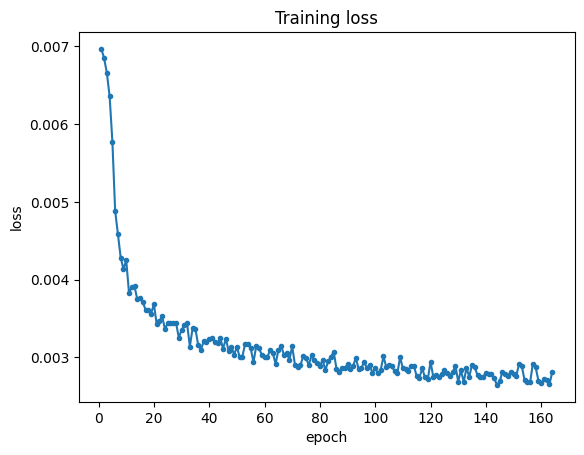

In [10]:
plt.figure()
plt.plot(np.arange(1, len(history) + 1), history, '.-')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.title('Training loss')
plt.show()


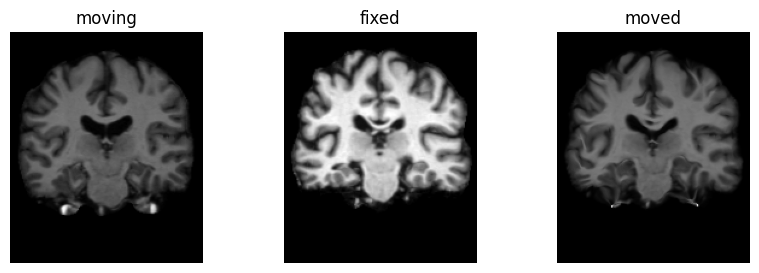

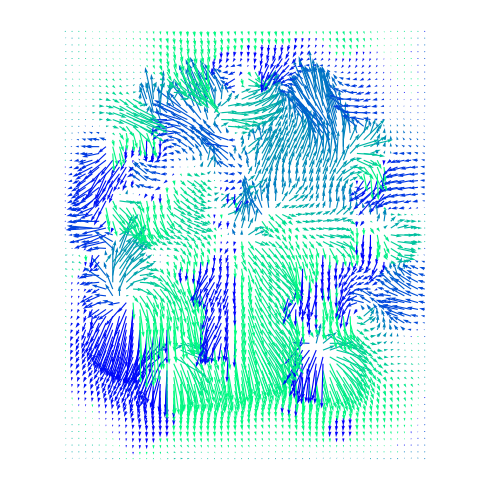

(<Figure size 500x500 with 1 Axes>, [<Axes: >])

In [11]:
model.eval()
with torch.no_grad():
    moving, fixed = sample_batch(x_val_tensor, batch_size=1, device=device, pairs=val_pair_indices)
    moved, flow = model(moving, fixed)

moving_np = moving[0, 0].cpu().numpy()
fixed_np = fixed[0, 0].cpu().numpy()
moved_np = moved[0, 0].cpu().numpy()
flow_np = flow[0].permute(1, 2, 0).cpu().numpy()

plt.figure(figsize=(10, 3))
for i, (img, title) in enumerate([(moving_np, 'moving'), (fixed_np, 'fixed'), (moved_np, 'moved')]):
    plt.subplot(1, 3, i + 1)
    plt.imshow(img, cmap='gray')
    plt.title(title)
    plt.axis('off')
plt.show()

step = 3
flow_ds = flow_np[::step, ::step, :]
ne.plot.flow([flow_ds], width=5)
